> **Latest postprocessing:** run only **Electric field versus x, 75 µm above the oxide** at the end. It uses the stored solution and does not run the solver. Earlier sections document construction, mesh repair, and the stationary solve.

# Place the mirror STL inside the global-zone trench

Edits **`C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph`** in place. No second MPH file is written. Close this model in COMSOL Desktop before running; reopen it after saving.

The existing SiO₂ occupies x,y = −250…250 µm and z = 0…12 µm. Its trench occupies x = −9.5…9.5 µm, y = −15…15 µm and z = 1…12 µm.

The STL is unitless; coordinates are interpreted as micrometres. Its long axis is original x, its flat back is original **+y**, and its bottom is original **−z**. Rotate −90° around z so that the 30 µm back faces the **+x trench wall**, then translate the back to x = 9.5 µm and the bottom to z = 1 µm. Center along y.

The STL long dimension is 30.00029945 µm. Scale **only that axis** by 30/30.00029945 (about −0.001%) to fit the nominal 30 µm trench; preserve the other dimensions. The original STL is not modified. Keep the mirror as a separate domain; no mirror material or electrical boundary condition is assumed.

Requirements: COMSOL 6.1, `MPh`, `numpy`, `matplotlib`. Cells run in order; the final cell saves only after the geometry checks pass.

Executed successfully: mirror is flush with the +x wall and rests on the trench floor. Both contact interfaces are verified in the outputs below. The import mesh is cached in the saved model; the temporary repair file is not needed to reopen it.

In [1]:
from pathlib import Path
import hashlib
import struct
import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import mph
from jpype import JArray, JDouble, JInt, JString

MODEL_PATH = Path(r"C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph")
STL_PATH = MODEL_PATH.parent / "Global_QCCD_FINAL_mirror.stl"
WALL_X_UM = 9.5
FLOOR_Z_UM = 1.0
TRENCH_LENGTH_UM = 30.0
TOL_UM = 1e-5

assert MODEL_PATH.is_file() and STL_PATH.is_file()
assert not Path(str(MODEL_PATH) + ".lock").exists(), "Close global_zone.mph in COMSOL first."
source_hash = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
stl_hash = hashlib.sha256(STL_PATH.read_bytes()).hexdigest()
strings = lambda values: JArray(JString)([str(v) for v in values])
doubles = lambda values: JArray(JDouble)([float(v) for v in values])
integers = lambda values: JArray(JInt)([int(v) for v in values])

## Inspect the STL and preview the placement

Triangles: 55532
Source bounds [um]: [-15.00014973 -11.94850063  -1.5       ] [15.00014973  0.84089029  8.49922752]
Scale on original x: 0.9999900183084568
Translation after rotation [um]: [8.65910971 0.         2.5       ]
Placed bounds [um]: [ -3.28939092 -15.           1.        ] [ 9.5        15.         10.99922752]
Clearance below top surface [um]: 1.000772476196289


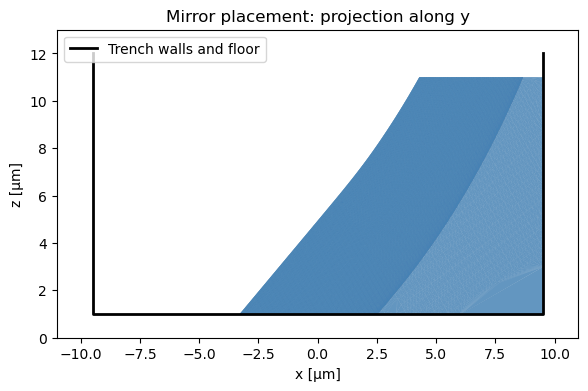

In [2]:
raw = STL_PATH.read_bytes()
n_triangles = struct.unpack_from("<I", raw, 80)[0]
assert len(raw) == 84 + 50*n_triangles, "Expected the supplied binary STL."
dtype = np.dtype([("normal", "<f4", (3,)), ("vertices", "<f4", (3,3)), ("attribute", "<u2")])
triangles = np.frombuffer(raw, dtype=dtype, offset=84)["vertices"].astype(float)
lo, hi = triangles.min(axis=(0,1)), triangles.max(axis=(0,1))
size = hi-lo
assert np.isfinite(triangles).all()
assert abs(size[0]-30) < 0.001, "Unexpected STL scale/orientation."

# Every undirected edge must have two incident triangles (closed surface).
vertices, ids = np.unique(triangles.reshape(-1,3), axis=0, return_inverse=True)
faces = ids.reshape(-1,3)
edges = np.sort(np.concatenate([faces[:,[0,1]], faces[:,[1,2]], faces[:,[2,0]]]), axis=1)
_, edge_counts = np.unique(edges, axis=0, return_counts=True)
assert np.all(edge_counts == 2), "STL is not a closed manifold surface."
areas = np.linalg.norm(np.cross(triangles[:,1]-triangles[:,0], triangles[:,2]-triangles[:,0]), axis=1)/2
back = np.all(np.abs(triangles[:,:,1]-hi[1]) < 1e-5, axis=1)
assert areas[back].sum() > 250, "Expected a broad, flat back at original +y."

long_axis_scale = TRENCH_LENGTH_UM/size[0]
shift = np.array([WALL_X_UM-hi[1], long_axis_scale*(lo[0]+hi[0])/2, FLOOR_Z_UM-lo[2]])
placed = np.stack([triangles[:,:,1], -long_axis_scale*triangles[:,:,0], triangles[:,:,2]], axis=-1)+shift
placed_lo, placed_hi = placed.min(axis=(0,1)), placed.max(axis=(0,1))
stl_volume = abs(np.einsum("ij,ij->i", triangles[:,0], np.cross(triangles[:,1],triangles[:,2])).sum()/6)
expected_mirror_volume = stl_volume*long_axis_scale
assert np.all(placed_lo >= np.array([-9.5,-15,1])-TOL_UM)
assert np.all(placed_hi <= np.array([9.5,15,12])+TOL_UM)
print("Triangles:", n_triangles)
print("Source bounds [um]:", lo, hi)
print("Scale on original x:", long_axis_scale)
print("Translation after rotation [um]:", shift)
print("Placed bounds [um]:", placed_lo, placed_hi)
print("Clearance below top surface [um]:", 12-placed_hi[2])

fig, ax = plt.subplots(figsize=(7,4))
ax.add_collection(PolyCollection(placed[:,:,[0,2]], facecolor="steelblue", edgecolor="none", alpha=0.6))
ax.plot([-9.5,-9.5,9.5,9.5], [12,1,1,12], color="black", lw=2, label="Trench walls and floor")
ax.set(xlim=(-11,11), ylim=(0,13), xlabel="x [µm]", ylabel="z [µm]", title="Mirror placement: projection along y")
ax.set_aspect("equal")
ax.legend(loc="upper left")
plt.show()

## Repair the flat back triangulation without moving vertices

The supplied STL contains four nearly collinear back-face triangles whose geometric normals point inward. COMSOL rejects its mesh topology. Retriangulate only that planar face using its existing boundary, preserving all boundary coordinates and the enclosed volume. A temporary STL carries these triangles into COMSOL; the original STL is untouched, and the temporary file is removed after saving. COMSOL stores the imported mesh inside the same MPH file. Rerun this notebook to reimport from the original source.

In [3]:
import numpy as np

def repair_planar_back(triangles):
    """Retriangulate the flat +y back without moving its boundary vertices."""
    vertices, index = np.unique(triangles.reshape(-1,3), axis=0, return_inverse=True)
    faces = index.reshape(-1,3)
    back = np.all(np.abs(triangles[:,:,1]-vertices[:,1].max()) < 1e-8, axis=1)
    bf = faces[back]
    edges = np.sort(np.concatenate([bf[:,[0,1]],bf[:,[1,2]],bf[:,[2,0]]]),axis=1)
    ue, counts = np.unique(edges,axis=0,return_counts=True)
    boundary = ue[counts==1]
    neighbors = {}
    for a,b in boundary:
        neighbors.setdefault(int(a),[]).append(int(b))
        neighbors.setdefault(int(b),[]).append(int(a))
    assert all(len(n)==2 for n in neighbors.values()), 'Back boundary is not a simple cycle.'
    loop=[min(neighbors)]
    previous=None
    while True:
        nxt=next(n for n in neighbors[loop[-1]] if n != previous)
        if nxt == loop[0]: break
        previous=loop[-1]
        loop.append(nxt)
        assert len(loop)<=len(neighbors)
    assert len(loop)==len(neighbors), 'Multiple boundary loops need separate handling.'
    coords=vertices[:,[0,2]]
    cross2=lambda a,b: a[...,0]*b[...,1]-a[...,1]*b[...,0]
    polygon=coords[loop]
    signed_area=cross2(polygon,np.roll(polygon,-1,axis=0)).sum()/2
    if signed_area<0: loop.reverse()
    remaining=loop.copy()
    out=[]
    while len(remaining)>3:
        found=False
        for k in range(len(remaining)):
            a,b,c=remaining[k-1],remaining[k],remaining[(k+1)%len(remaining)]
            pa,pb,pc=coords[[a,b,c]]
            if cross2(pb-pa,pc-pa)<=1e-13: continue
            others=[i for i in remaining if i not in (a,b,c)]
            p=coords[others]
            inside=(cross2(pb-pa,p-pa)>=-1e-13)&(cross2(pc-pb,p-pb)>=-1e-13)&(cross2(pa-pc,p-pc)>=-1e-13)
            if np.any(inside): continue
            out.append([a,c,b]) # CCW in (x,z) gives -y; reverse for +y.
            remaining.pop(k)
            found=True
            break
        if not found: raise RuntimeError('Cannot triangulate the original back boundary.')
    a,b,c=remaining
    out.append([a,c,b])
    repaired=vertices[np.concatenate([faces[~back],np.asarray(out,dtype=int)])]
    print('Back repair: old/new triangles',int(back.sum()),len(out),'boundary vertices',len(loop),flush=True)
    return repaired

import tempfile
repaired_triangles = repair_planar_back(triangles)
assert np.array_equal(np.unique(repaired_triangles.reshape(-1,3),axis=0), vertices)
repaired_volume = abs(np.einsum("ij,ij->i", repaired_triangles[:,0], np.cross(repaired_triangles[:,1],repaired_triangles[:,2])).sum()/6)
assert abs(repaired_volume-stl_volume) < 1e-8
_, repaired_ids = np.unique(repaired_triangles.reshape(-1,3),axis=0,return_inverse=True)
rf = repaired_ids.reshape(-1,3)
re = np.concatenate([rf[:,[0,1]],rf[:,[1,2]],rf[:,[2,0]]])
_, ri, rc = np.unique(np.sort(re,axis=1),axis=0,return_inverse=True,return_counts=True)
assert np.all(rc == 2)
assert np.all(np.bincount(ri,weights=np.where(re[:,0]<re[:,1],1,-1)) == 0)

temporary_stl = tempfile.TemporaryDirectory(prefix="comsol_mirror_")
REPAIRED_STL_PATH = Path(temporary_stl.name)/"mirror_repaired.stl"
records = np.zeros(len(repaired_triangles), dtype=dtype)
records["vertices"] = repaired_triangles
normals = np.cross(repaired_triangles[:,1]-repaired_triangles[:,0],repaired_triangles[:,2]-repaired_triangles[:,0])
normals /= np.linalg.norm(normals,axis=1)[:,None]
records["normal"] = normals
header = b"Back face retriangulated; original vertex coordinates preserved".ljust(80,b" ")
REPAIRED_STL_PATH.write_bytes(header+struct.pack("<I",len(records))+records.tobytes())
print("Repair verified: identical vertices and volume; closed, consistently oriented surface.")

Back repair: old/new triangles 66 66 boundary vertices 68


Repair verified: identical vertices and volume; closed, consistently oriented surface.


## Load the existing model and import the repaired STL

The COMSOL geometry kernel supports mesh-derived geometry. The import disables mesh simplification to preserve the supplied surface. Rerunning replaces only the mirror features created here.

In [4]:
geometry_validated = False  # Invalidate the save guard before editing/rechecking.
mph.option("session", "stand-alone")
client = mph.start(version="6.1", cores=4)
model = client.load(str(MODEL_PATH))
j = model.java
comp = j.component("comp1")
geom = comp.geom("geom1")
assert np.isclose(j.param().evaluate("trench_width")*1e6, 19)
assert np.isclose(j.param().evaluate("trench_length")*1e6, 30)
assert np.isclose(j.param().evaluate("oxide_thickness")*1e6, 12)
assert np.isclose(j.param().evaluate("trench_depth")*1e6, 11)

# Remember only the mesh part used by our own importer for safe reruns.
old_mesh = None
if "mirror_import" in list(geom.feature().tags()):
    old_mesh = str(geom.feature("mirror_import").getString("mesh"))
for tag in ["mirror_place", "mirror_rotate", "mirror_scale", "mirror_import"]:
    if tag in list(geom.feature().tags()):
        geom.feature().remove(tag)
if old_mesh and old_mesh != "none" and old_mesh in list(j.mesh().tags()):
    j.mesh().remove(old_mesh)

geom.geomRep("comsol")
geom.lengthUnit("um")
geom.run("dif1")
geom.create("mirror_import", "Import")
imp = geom.feature("mirror_import")
imp.label("Mirror STL: repaired back triangulation (um)")
imp.comments("Original source: "+str(STL_PATH)+". Flat back retriangulated without moving vertices; temporary import data cached in this model. Rerun global_zone.ipynb to reimport.")
imp.set("type", "mesh")
imp.set("meshfilename", str(REPAIRED_STL_PATH))
imp.set("simplifymesh", "off")
imp.set("selresult", "on")
imp.importData()
geom.run("mirror_import")

def object_measure(tag):
    measure = geom.measure()
    objects = [str(name) for name in geom.objectNames() if str(name) == tag or str(name).startswith(tag+"(")]
    assert len(objects) == 1, f"Expected one solid object for {tag}: {objects}"
    measure.selection().init(3)
    measure.selection().set(objects[0], integers([1]))
    return np.array(measure.getBoundingBox(), dtype=float), float(measure.getVolume())

raw_box, raw_volume = object_measure("mirror_import")
expected_raw_box = np.array([lo[0],hi[0],lo[1],hi[1],lo[2],hi[2]])
assert np.allclose(raw_box, expected_raw_box, atol=TOL_UM, rtol=0), f"STL import units mismatch: {raw_box}"
print("Imported STL bounds [um]:", raw_box)
print("Imported mirror volume [um^3]:", raw_volume)

Imported STL bounds [um]: [-15.00014973  15.00014973 -11.94850063   0.84089029  -1.5
   8.49922752]
Imported mirror volume [um^3]: 1579.2153542882024


## Normalize the length, rotate, and place the mirror

In [5]:
geometry_validated = False  # Invalidate the save guard before editing/rechecking.
j.param().set("mirror_long_scale", str(long_axis_scale), "Correct STL long axis to nominal 30 um")
for axis, value in zip("xyz", shift):
    j.param().set("mirror_d"+axis, f"{value:.16g}[um]", "Mirror translation after rotation")

geom.create("mirror_scale", "Scale")
scale = geom.feature("mirror_scale")
scale.label("Normalize 30 um length (original x only)")
scale.selection("input").set(strings(["mirror_import"]))
scale.set("factor", strings(["mirror_long_scale", "1", "1"]))
scale.set("pos", doubles([0,0,0]))

geom.create("mirror_rotate", "Rotate")
rotate = geom.feature("mirror_rotate")
rotate.label("Rotate -90 deg about z: flat back toward +x")
rotate.selection("input").set(strings(["mirror_scale"]))
rotate.set("axis", doubles([0,0,1]))
rotate.set("pos", doubles([0,0,0]))
rotate.set("rot", -90.0)

geom.create("mirror_place", "Move")
move = geom.feature("mirror_place")
move.label("Mirror flush with +x wall, resting on trench floor")
move.selection("input").set(strings(["mirror_rotate"]))
move.set("displ", strings(["mirror_dx", "mirror_dy", "mirror_dz"]))
move.set("selresult", "on")
geom.run("mirror_place")
mirror_box, mirror_volume = object_measure("mirror_place")
expected_box = np.array([placed_lo[0],placed_hi[0],placed_lo[1],placed_hi[1],placed_lo[2],placed_hi[2]])
assert np.allclose(mirror_box, expected_box, atol=TOL_UM, rtol=0), mirror_box
# COMSOL's geometry Measure uses a rendering triangulation, so its curved-body
# volume is approximate. Compare the rigid transform against the same estimator.
assert np.isclose(mirror_volume, raw_volume*long_axis_scale, rtol=1e-6)
print("Placed COMSOL mirror bounds [um]:", mirror_box)
print("Mirror volume [um^3]:", mirror_volume)

Placed COMSOL mirror bounds [um]: [ -3.28939104   9.5        -15.          15.           1.
  10.99922752]
Mirror volume [um^3]: 1579.199563985636


## Finalize and validate the two domains

Form Union keeps interior boundaries so the mirror and oxide remain separate domains. The oxide material remains restricted to its original geometry selection. A mirror material can be assigned later.

COMSOL geometry volume measurements use a rendering triangulation and are approximate for curved objects ([API documentation](https://doc.comsol.com/6.4/doc/com.comsol.help.comsol/comsol_api_geom.48.047.html)). The STL volume is computed directly above; the COMSOL mirror volume is a 1% sanity check, not an exact mesh-volume comparison. Bounds and contact locations are checked separately.

In [6]:
geometry_validated = False  # Invalidate the save guard before editing/rechecking.
fin = geom.feature("fin")
fin.set("action", "union")
# Form Union preserves interfaces between input domains automatically.
# Tight absolute tolerance avoids modifying the small trench with chip-scale repair tolerances.
fin.set("repairtoltype", "absolute")
fin.set("absrepairtol", 1e-6)
geom.run()

mirror_domains = np.array(comp.selection("geom1_mirror_place_dom").entities(3), dtype=int)
oxide_domains = np.array(comp.selection("geom1_dif1_dom").entities(3), dtype=int)
assert geom.getNDomains() == 2, f"Expected oxide + mirror, got {geom.getNDomains()} domains."
assert len(mirror_domains) == 1 and len(oxide_domains) == 1
assert not np.intersect1d(mirror_domains, oxide_domains).size

def domain_measure(domains):
    measure = geom.measureFinal()
    measure.selection().geom(3)
    measure.selection().set(integers(domains))
    return np.array(measure.getBoundingBox(), dtype=float), float(measure.getVolume())

final_box, final_mirror_volume = domain_measure(mirror_domains)
oxide_box, oxide_volume = domain_measure(oxide_domains)
assert np.allclose(final_box, expected_box, atol=TOL_UM, rtol=0)
assert np.isclose(final_mirror_volume, expected_mirror_volume, rtol=0.01)
assert abs(oxide_volume-2993730) < 0.01, "Mirror overlaps oxide or trench was changed."
assert np.isclose(final_box[1], WALL_X_UM, atol=TOL_UM, rtol=0)
assert np.isclose(final_box[4], FLOOR_Z_UM, atol=TOL_UM, rtol=0)
assert final_box[0] >= -9.5-TOL_UM and final_box[5] <= 12+TOL_UM
comp.selection("geom1_mirror_place_dom").label("Mirror domain")
comp.selection("geom1_dif1_dom").label("SiO2 domain")

# Shared faces prove actual contact, rather than just overlapping bounding boxes.
mirror_faces = np.array(geom.getAdj(3,2,int(mirror_domains[0])), dtype=int)
oxide_faces = np.array(geom.getAdj(3,2,int(oxide_domains[0])), dtype=int)
shared_faces = np.intersect1d(mirror_faces, oxide_faces)
wall_contact_area = floor_contact_area = 0.0
for face in shared_faces:
    measure = geom.measureFinal()
    measure.selection().geom(2)
    measure.selection().set(integers([face]))
    box = np.array(measure.getBoundingBox(),dtype=float)
    area = float(measure.getVolume())
    if np.allclose(box[:2],WALL_X_UM,atol=TOL_UM,rtol=0):
        wall_contact_area += area
    if np.allclose(box[4:],FLOOR_Z_UM,atol=TOL_UM,rtol=0):
        floor_contact_area += area
assert wall_contact_area > 0.99*areas[back].sum()*long_axis_scale, "Mirror back is not in full contact with the +x wall."
assert floor_contact_area > 250, "Mirror is not resting on the trench floor."
geometry_validated = True
print("Validated:", geom.getNDomains(), "domains")
print("Mirror domain:", mirror_domains, "bounds [um]:", final_box)
print("SiO2 volume [um^3]:", oxide_volume)
print("Mirror volume [um^3]:", final_mirror_volume)
print("Wall gap [um]:", WALL_X_UM-final_box[1])
print("Floor gap [um]:", final_box[4]-FLOOR_Z_UM)
print("Shared +x wall contact area [um^2]:", wall_contact_area)
print("Shared floor contact area [um^2]:", floor_contact_area)

Validated: 2 domains
Mirror domain: [2] bounds [um]: [ -3.28939104   9.5        -15.          15.           1.
  10.99922752]
SiO2 volume [um^3]: 2993730.0049374267
Mirror volume [um^3]: 1579.8373610955564
Wall gap [um]: 0.0
Floor gap [um]: 0.0
Shared +x wall contact area [um^2]: 299.97505455949636
Shared floor contact area [um^2]: 268.23145869097357


## Save to the same model file

This cell overwrites only `MODEL_PATH`. It refuses to save if the source model or STL changed externally during the session. No solve or meshing is performed.

In [7]:
assert geometry_validated
assert hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest() == source_hash, "Source model changed externally; reload before saving."
assert hashlib.sha256(STL_PATH.read_bytes()).hexdigest() == stl_hash, "STL changed externally; rerun before saving."
model.save(str(MODEL_PATH))
source_hash = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
print("Saved in place:", MODEL_PATH)
client.remove(model)  # Release the file so it can be reopened in COMSOL Desktop.
temporary_stl.cleanup()  # Imported mesh data are cached in the MPH file.

Saved in place: C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph


# Mesh repair after adding air and overhang

Run this section independently on the current `global_zone.mph`; do not rerun the earlier two-domain construction cells. The source model contains four domains: air, SiO₂, overhang, and mirror.

The failed tetrahedral mesh reported faces 19 and 24 near y = 15 µm. The imported mirror end is slightly nonplanar, leaving an air sliver up to approximately 0.00012 µm wide beside the trench wall. Set **Form Union's absolute repair tolerance to 0.0005 µm (0.5 nm)** so the nominally contacting faces form a shared interface. This is far smaller than the overhang's 0.5 µm clearance.

Keep the existing geometry objects, mesh sizing, air box, overhang, materials, Ground, and Terminal settings. Build the entire tetrahedral mesh and check every domain before saving **the same MPH file**. This section uses the cached mirror mesh; it does not need the temporary STL from the earlier import.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import mph
from jpype import JArray, JInt

REPAIR_MODEL_PATH = Path(r"C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph")
REPAIR_TOLERANCE_UM = 0.0005
assert not Path(str(REPAIR_MODEL_PATH)+".lock").exists(), "Close this model in COMSOL before editing it."
repair_source_hash = hashlib.sha256(REPAIR_MODEL_PATH.read_bytes()).hexdigest()
mesh_repair_validated = False
mph.option("session", "stand-alone")
repair_client = mph.start(version="6.1", cores=4)
repair_model = repair_client.load(str(REPAIR_MODEL_PATH))
repair_java = repair_model.java
repair_comp = repair_java.component("comp1")
repair_geom = repair_comp.geom("geom1")
repair_mesh = repair_comp.mesh("mesh1")

def repair_measure(dim, entities):
    measure = repair_geom.measureFinal()
    measure.selection().geom(dim)
    measure.selection().set(JArray(JInt)([int(i) for i in entities]))
    return np.array(measure.getBoundingBox(), dtype=float), float(measure.getVolume())

repair_original_features = list(repair_geom.feature().tags())
repair_original_parameters = {str(k): str(repair_java.param().get(k)) for k in repair_java.param().varnames()}
repair_original_blocks = {tag: {prop: list(repair_geom.feature(tag).getStringArray(prop))
                               for prop in ("size", "pos")}
                          for tag in ("blk1", "blk2")}
repair_original_materials = {str(tag): list(repair_comp.material(tag).selection().entities(3))
                             for tag in repair_comp.material().tags()}
repair_original_bc = {tag: list(repair_comp.physics("es").feature(tag).selection().entities(2))
                      for tag in ("gnd1", "term1")}
repair_original_bc_bounds = {int(face): repair_measure(2,[face])[0]
                             for faces in repair_original_bc.values() for face in faces}
repair_original_domain_bounds = {d: repair_measure(3,[d])[0]
                                 for d in range(1,repair_geom.getNDomains()+1)}
assert len(repair_original_domain_bounds) == 4, "Expected the saved air/oxide/overhang/mirror model."
print("Loaded current model with", repair_geom.getNDomains(), "domains.")

Loaded current model with 4 domains.


In [2]:
mesh_repair_validated = False
repair_geom.feature("fin").set("repairtoltype", "absolute")
repair_geom.feature("fin").set("absrepairtol", REPAIR_TOLERANCE_UM)
repair_geom.run()

# The repair changes only the Form Union tolerance, not the user's inputs.
assert list(repair_geom.feature().tags()) == repair_original_features
assert {str(k): str(repair_java.param().get(k)) for k in repair_java.param().varnames()} == repair_original_parameters
for tag, properties in repair_original_blocks.items():
    for prop, values in properties.items():
        assert list(repair_geom.feature(tag).getStringArray(prop)) == values
assert repair_geom.getNDomains() == 4
for domain, bounds in repair_original_domain_bounds.items():
    assert np.allclose(repair_measure(3,[domain])[0], bounds, atol=REPAIR_TOLERANCE_UM, rtol=0)
for tag, entities in repair_original_materials.items():
    assert list(repair_comp.material(tag).selection().entities(3)) == entities
for tag, entities in repair_original_bc.items():
    assert list(repair_comp.physics("es").feature(tag).selection().entities(2)) == entities
for face, bounds in repair_original_bc_bounds.items():
    assert np.allclose(repair_measure(2,[face])[0], bounds, atol=REPAIR_TOLERANCE_UM, rtol=0)

# Verify that the mirror's +y side now contacts oxide instead of trapping a thin air sliver.
oxide_domain = int(repair_comp.selection("geom1_dif1_dom").entities(3)[0])
mirror_domain = int(repair_comp.selection("geom1_mirror_place_dom").entities(3)[0])
shared = np.intersect1d(repair_geom.getAdj(3,2,oxide_domain), repair_geom.getAdj(3,2,mirror_domain))
positive_y_contacts = []
for face in shared:
    bounds, area = repair_measure(2,[face])
    if np.allclose(bounds[2:4], 15, atol=REPAIR_TOLERANCE_UM, rtol=0) and area > 1:
        positive_y_contacts.append(int(face))
assert positive_y_contacts, "The mirror-to-trench sliver has not been removed."
print("Repaired +y mirror/oxide interface:", positive_y_contacts)

# Keep the user's existing Size and Free Tetrahedral settings.
repair_mesh.clearMesh()
repair_mesh.run()
repair_stats = repair_mesh.stat()
repair_domain_tets = {}
for domain in range(1,repair_geom.getNDomains()+1):
    repair_stats.selection().geom(3)
    repair_stats.selection().set(JArray(JInt)([domain]))
    assert repair_stats.isComplete(), f"Domain {domain} is not completely meshed."
    repair_domain_tets[domain] = int(repair_stats.getNumElem("tet"))
    assert repair_domain_tets[domain] > 0
repair_stats.selection().geom(3)
repair_stats.selection().all()
assert repair_stats.isComplete()
assert repair_stats.getMinQuality("tet") > 0
assert repair_stats.getMinVolume("tet") > 0
mesh_repair_validated = True
print("Tetrahedra per domain:", repair_domain_tets)
print("Total tetrahedra:", repair_stats.getNumElem("tet"))
print("Minimum element quality:", repair_stats.getMinQuality("tet"))
print("Mean element quality:", repair_stats.getMeanQuality("tet"))
print("All domains meshed successfully; no intersecting-face meshing error.")
print("Air box, overhang, material selections, and electrical selections preserved.")

Repaired +y mirror/oxide interface: [24]


Tetrahedra per domain: {1: 205555, 2: 44005, 3: 3769, 4: 4447}
Total tetrahedra: 257776
Minimum element quality: 0.2254
Mean element quality: 0.6873
All domains meshed successfully; no intersecting-face meshing error.
Air box, overhang, material selections, and electrical selections preserved.


In [3]:
assert mesh_repair_validated
assert hashlib.sha256(REPAIR_MODEL_PATH.read_bytes()).hexdigest() == repair_source_hash, "Model changed externally; reload before saving."
repair_model.save(str(REPAIR_MODEL_PATH))
repair_source_hash = hashlib.sha256(REPAIR_MODEL_PATH.read_bytes()).hexdigest()
repair_client.remove(repair_model)
print("Saved repaired geometry and full tetrahedral mesh in place:", REPAIR_MODEL_PATH)

# Confirm the stored mesh survives reopening; no additional save or MPH file.
reopened_model = repair_client.load(str(REPAIR_MODEL_PATH))
try:
    reopened_stats = reopened_model.java.component("comp1").mesh("mesh1").stat()
    reopened_stats.selection().geom(3)
    reopened_stats.selection().all()
    assert reopened_stats.isComplete()
    assert reopened_stats.getNumElem("tet") == sum(repair_domain_tets.values())
    assert reopened_stats.getMinQuality("tet") > 0
    print("Reopened saved model: complete mesh retained.")
finally:
    repair_client.remove(reopened_model)

Saved repaired geometry and full tetrahedral mesh in place: C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph


Reopened saved model: complete mesh retained.


# Ground metallized domains and solve Stationary

Domains **3 (overhang)** and **4 (mirror)** represent ideal conductors held at **0 V**, as requested. Add a separate **Domain Terminal** in Voltage mode to each domain. This enforces a constant potential in each conductor and avoids treating its interior as an ordinary dielectric requiring an assigned permittivity. [COMSOL's domain-terminal example](https://doc.comsol.com/6.1/doc/com.comsol.help.models.mems.biased_resonator_3d_basic/models.mems.biased_resonator_3d_basic.pdf)

Preserve **Terminal 1**, including faces **16–19**, its **Voltage** mode, and its **1 V** value. This is the existing excitation referred to as the charge surface; it is not changed to a surface-charge-density condition. Existing Ground faces belonging to the two conductors are handled by the domain terminals instead, while the remaining original Ground faces stay selected. Geometry, mesh, materials, and the existing stationary solver settings are retained.

Run these cells independently. They solve the stationary study, verify Vmin = Vmax = 0 V in both conductor volumes, and save the solution to the same `global_zone.mph`.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import mph
from jpype import JArray, JInt

CONDUCTOR_MODEL_PATH = Path(r"C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph")
assert not Path(str(CONDUCTOR_MODEL_PATH)+".lock").exists(), "Close this model in COMSOL before editing."
conductor_source_hash = hashlib.sha256(CONDUCTOR_MODEL_PATH.read_bytes()).hexdigest()
conductor_solution_validated = False
mph.option("session", "stand-alone")
conductor_client = mph.start(version="6.1", cores=8)
conductor_model = conductor_client.load(str(CONDUCTOR_MODEL_PATH))
conductor_java = conductor_model.java
conductor_comp = conductor_java.component("comp1")
conductor_geom = conductor_comp.geom("geom1")
conductor_es = conductor_comp.physics("es")
assert conductor_geom.getNDomains() == 4
conductor_original_features = list(conductor_geom.feature().tags())
conductor_original_mesh_count = int(conductor_comp.mesh("mesh1").stat().getNumElem("tet"))
assert conductor_original_mesh_count > 0
conductor_original_materials = {str(tag): list(conductor_comp.material(tag).selection().entities(3))
                                for tag in conductor_comp.material().tags()}

def excitation_snapshot():
    node = conductor_es.feature("term1")
    return {"faces": list(node.selection().entities(2)),
            "active": bool(node.isActive()),
            **{key: str(node.getString(key)) for key in
               ("TerminalName", "TerminalType", "V0", "Q0")}}

preserved_excitation = excitation_snapshot()
original_ground_faces = list(conductor_es.feature("gnd1").selection().entities(2))
conductor_faces = sorted({int(face) for domain in (3,4)
                          for face in conductor_geom.getAdj(3,2,domain)})
assert not set(conductor_faces).intersection(preserved_excitation["faces"]), "Metal grounding would overlap the preserved excitation."
print("Preserved surface excitation:", preserved_excitation)

for domain, label in [(3,"Overhang"),(4,"Mirror")]:
    tag = f"metal_ground_{domain}"
    if tag not in list(conductor_es.feature().tags()):
        conductor_es.create(tag, "DomainTerminal", 3)
    node = conductor_es.feature(tag)
    assert str(node.getType()) == "DomainTerminal"
    node.selection().set(JArray(JInt)([domain]))
    node.set("TerminalType", "Voltage")
    node.set("V0", "0[V]")
    node.set("TerminalName", f"G{domain}")
    node.label(f"{label} grounded conductor (0 V)")

# Domain terminals cover every conductor face, including the previously omitted face 24.
# Retain other Ground faces and avoid imposing the same constraint twice on the metals.
remaining_ground_faces = [face for face in original_ground_faces if face not in conductor_faces]
conductor_es.feature("gnd1").selection().set(JArray(JInt)(remaining_ground_faces))
assert excitation_snapshot() == preserved_excitation
print("Grounded conductor domains: 3, 4 at 0 V")
print("Remaining original Ground faces:", remaining_ground_faces)

Preserved surface excitation: {'faces': [16, 17, 18, 19], 'active': True, 'TerminalName': '1', 'TerminalType': 'Voltage', 'V0': '1', 'Q0': '0'}


Grounded conductor domains: 3, 4 at 0 V
Remaining original Ground faces: [9]


In [2]:
conductor_solution_validated = False
conductor_java.study("std1").run()

def conductor_voltage_extrema(java_model, domain):
    values = []
    for feature_type in ("MinVolume", "MaxVolume"):
        tag = f"verify_metal_{domain}_{feature_type}"
        numerical = java_model.result().numerical()
        if tag in list(numerical.tags()):
            numerical.remove(tag)
        node = numerical.create(tag, feature_type)
        try:
            node.selection().set(JArray(JInt)([domain]))
            node.set("expr", "V")
            result = np.array(node.getReal(), dtype=float).ravel()
            assert result.size and np.isfinite(result).all()
            values.append(float(result[0]))
        finally:
            numerical.remove(tag)
    return values

conductor_voltage_report = {}
for domain in (3,4):
    limits = conductor_voltage_extrema(conductor_java, domain)
    assert np.allclose(limits, 0, atol=1e-10, rtol=0), f"Domain {domain} is not uniformly grounded: {limits}"
    conductor_voltage_report[domain] = limits
assert excitation_snapshot() == preserved_excitation
assert list(conductor_geom.feature().tags()) == conductor_original_features
assert conductor_comp.mesh("mesh1").stat().getNumElem("tet") == conductor_original_mesh_count
for tag, domains in conductor_original_materials.items():
    assert list(conductor_comp.material(tag).selection().entities(3)) == domains
conductor_solution_validated = True
print("Stationary study solved successfully.")
print("Conductor [minimum, maximum] voltage [V]:", conductor_voltage_report)
print("Existing surface excitation, geometry, mesh and material selections preserved.")

Stationary study solved successfully.
Conductor [minimum, maximum] voltage [V]: {3: [0.0, 0.0], 4: [0.0, 0.0]}
Existing surface excitation, geometry, mesh and material selections preserved.


In [3]:
assert conductor_solution_validated
assert hashlib.sha256(CONDUCTOR_MODEL_PATH.read_bytes()).hexdigest() == conductor_source_hash, "Model changed externally; reload before saving."
conductor_model.save(str(CONDUCTOR_MODEL_PATH))
conductor_source_hash = hashlib.sha256(CONDUCTOR_MODEL_PATH.read_bytes()).hexdigest()
conductor_client.remove(conductor_model)
print("Saved conductor conditions and stationary solution in place:", CONDUCTOR_MODEL_PATH)

reopened_conductor_model = conductor_client.load(str(CONDUCTOR_MODEL_PATH))
try:
    for domain in (3,4):
        assert np.allclose(conductor_voltage_extrema(reopened_conductor_model.java,domain), 0, atol=1e-10, rtol=0)
    saved_terminal = reopened_conductor_model.java.component("comp1").physics("es").feature("term1")
    assert list(saved_terminal.selection().entities(2)) == preserved_excitation["faces"]
    for key in ("TerminalName", "TerminalType", "V0", "Q0"):
        assert str(saved_terminal.getString(key)) == preserved_excitation[key]
    print("Reopened saved solution: both conductor domains remain at 0 V; original excitation retained.")
finally:
    conductor_client.remove(reopened_conductor_model)

Saved conductor conditions and stationary solution in place: C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph


Reopened saved solution: both conductor domains remain at 0 V; original excitation retained.


# Electric field versus x, 75 µm above the oxide

Use the existing stationary solution. The oxide top is at z = 12 µm, so **75 µm above the oxide means z = 87 µm** in the model. Create a Cut Line 3D along **y = 0**, from **x = −250 to +250 µm**, spanning the oxide width. Plot **es.Ex, es.Ey, and es.Ez** versus the x coordinate in µm, with electric field in V/m.

Only result datasets and plots are added. No geometry build, mesh build, or solve is invoked. The stored solution vector is checked before and after postprocessing. Save to the same MPH file.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import mph
from jpype import JArray, JInt, JString

FIELD_MODEL_PATH = Path(r"C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph")
HEIGHT_ABOVE_OXIDE_UM = 75.0
assert not Path(str(FIELD_MODEL_PATH)+".lock").exists(), "Close the model in COMSOL before saving changes."
field_source_hash = hashlib.sha256(FIELD_MODEL_PATH.read_bytes()).hexdigest()
field_plot_validated = False
mph.option("session", "stand-alone")
field_client = mph.start(version="6.1", cores=4)
field_model = field_client.load(str(FIELD_MODEL_PATH))
field_java = field_model.java
field_geom = field_java.component("comp1").geom("geom1")
assert not field_java.sol("sol1").isEmpty(), "A stored stationary solution is required."
def solution_fingerprint(java_model):
    return hashlib.sha256(np.asarray(java_model.sol("sol1").getU(), dtype=np.float64).tobytes()).hexdigest()
field_solution_hash = solution_fingerprint(field_java)

oxide_domains = list(field_java.component("comp1").selection("geom1_dif1_dom").entities(3))
measure = field_geom.measureFinal()
measure.selection().geom(3)
measure.selection().set(JArray(JInt)(oxide_domains))
oxide_bounds_um = np.array(measure.getBoundingBox(),dtype=float)
assert str(field_geom.lengthUnit()) in ("um", "µm", "μm")
x_min_um, x_max_um = oxide_bounds_um[:2]
z_line_um = oxide_bounds_um[5]+HEIGHT_ABOVE_OXIDE_UM

datasets = field_java.result().dataset()
solution_datasets = [str(tag) for tag in datasets.tags()
                     if str(field_java.result().dataset(tag).getType()) == "Solution"
                     and str(field_java.result().dataset(tag).getString("solution")) == "sol1"]
assert solution_datasets, "No dataset referring to the stored stationary solution."
line_tag = "field_line_75um"
if line_tag not in list(datasets.tags()):
    datasets.create(line_tag,"CutLine3D")
line = field_java.result().dataset(line_tag)
line.label(f"y = 0, {HEIGHT_ABOVE_OXIDE_UM:g} um above oxide (z = {z_line_um:g} um)")
line.set("data",solution_datasets[0])
line.set("method","twopoint")
line.set("bounded","on")
points = [[f"{x_min_um:.16g}[um]","0[um]",f"{z_line_um:.16g}[um]"],
          [f"{x_max_um:.16g}[um]","0[um]",f"{z_line_um:.16g}[um]"]]
line.set("genpoints",JArray(JString,2)(points))

plot_tag = "field_components_75um"
if plot_tag not in list(field_java.result().tags()):
    field_java.result().create(plot_tag,"PlotGroup1D")
plot = field_java.result(plot_tag)
plot.label("Ex, Ey, Ez vs x - 75 um above oxide, y = 0")
plot.set("data",line_tag)
for tag, expr, label, color in [("ex","es.Ex","Ex","blue"),
                                ("ey","es.Ey","Ey","red"),
                                ("ez","es.Ez","Ez","green")]:
    if tag not in list(plot.feature().tags()):plot.create(tag,"LineGraph")
    graph = plot.feature(tag)
    graph.label(label+" versus x")
    graph.set("expr",expr)
    graph.set("unit","V/m")
    graph.set("xdata","expr")
    graph.set("xdataexpr","x")
    graph.set("xdataunit","um")
    graph.set("legend","on")
    graph.set("legendmethod","manual")
    graph.set("legends",JArray(JString)([label]))
    graph.set("linecolor",color)
    graph.set("resolution","fine")
plot.run()  # Evaluate/render the result plot only; this does not run a study.
print(f"Cut line: x = {x_min_um:g} ... {x_max_um:g} um, y = 0, z = {z_line_um:g} um.")
print("Created COMSOL plot:",plot.label())

Cut line: x = -250 ... 250 um, y = 0, z = 87 um.
Created COMSOL plot: Ex, Ey, Ez vs x - 75 um above oxide, y = 0


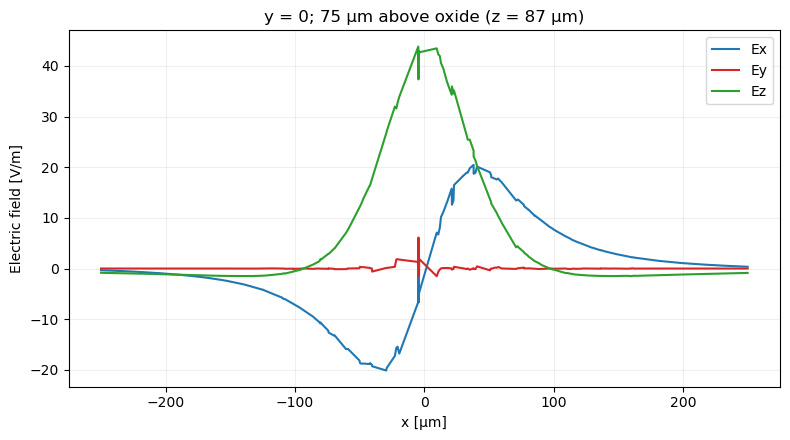

Verified line coordinates and finite Ex, Ey, Ez values at 506 points.
Stored solution unchanged; no solve performed.


In [2]:
# Evaluate the same cut line for a notebook preview and coordinate checks.
eval_tag = "verify_field_line_75um"
numerical = field_java.result().numerical()
if eval_tag in list(numerical.tags()):numerical.remove(eval_tag)
node = numerical.create(eval_tag,"Interp")
try:
    node.set("data",line_tag)
    node.set("expr",JArray(JString)(["x","y","z","es.Ex","es.Ey","es.Ez"]))
    node.set("unit",JArray(JString)(["um","um","um","V/m","V/m","V/m"]))
    field_samples = np.asarray(node.getData(),dtype=float)[:,0,:]
finally:
    numerical.remove(eval_tag)
assert np.isfinite(field_samples).all()
assert field_samples.shape[0] == 6 and field_samples.shape[1] > 1
assert np.allclose(field_samples[1],0,atol=1e-8,rtol=0)
assert np.allclose(field_samples[2],z_line_um,atol=1e-8,rtol=0)
assert np.isclose(field_samples[0].min(),x_min_um,atol=1e-6,rtol=0)
assert np.isclose(field_samples[0].max(),x_max_um,atol=1e-6,rtol=0)
order = np.argsort(field_samples[0])
fig, ax = plt.subplots(figsize=(8,4.5))
for row,label,color in [(3,"Ex","tab:blue"),(4,"Ey","tab:red"),(5,"Ez","tab:green")]:
    ax.plot(field_samples[0,order],field_samples[row,order],label=label,color=color)
ax.set(xlabel="x [µm]",ylabel="Electric field [V/m]",
       title=f"y = 0; {HEIGHT_ABOVE_OXIDE_UM:g} µm above oxide (z = {z_line_um:g} µm)")
ax.legend(loc="best")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()
assert solution_fingerprint(field_java) == field_solution_hash, "Stored solution changed unexpectedly."
field_plot_validated = True
print("Verified line coordinates and finite Ex, Ey, Ez values at",field_samples.shape[1],"points.")
print("Stored solution unchanged; no solve performed.")

In [3]:
assert field_plot_validated
assert hashlib.sha256(FIELD_MODEL_PATH.read_bytes()).hexdigest() == field_source_hash, "Model changed externally; reload before saving."
field_model.save(str(FIELD_MODEL_PATH))
field_client.remove(field_model)
print("Saved cut line and field-component plot to the same model:",FIELD_MODEL_PATH)

Saved cut line and field-component plot to the same model: C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph


## Refine air near the evaluation plane and add 2D field slices

The oxide top is at z = 12 um, so 75 um above it is **z = 87 um**. Target 5 um elements throughout the air band z = 77...97 um, grading back toward 21 um outside the band. A domain-selected Size Expression avoids changing the geometry or electrical boundary selections.

Create an xy Cut Plane and separate 2D surface plots of Ex, Ey, Ez, and |E|. **Build the mesh only; do not solve.** The stored solution and plots still represent the previous mesh until Study 1 is computed again. Earlier notebook sections are historical operations; execute only this section for this update.

API references: [Size Expression](https://doc.comsol.com/6.3/doc/com.comsol.help.comsol/comsol_api_mesh.49.100.html), [mesh-size units](https://doc.comsol.com/6.4/doc/com.comsol.help.comsol/comsol_ref_mesh.24.86.html).

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import mph
from jpype import JArray, JInt

SLICE_MODEL_PATH = Path(r"C:\Users\Administrator\Desktop\YiyangZhi\charging\global_zone.mph")
SLICE_HEIGHT_UM = 75.0
AIR_TARGET_UM = 5.0
AIR_BAND_HALF_WIDTH_UM = 10.0
assert not Path(str(SLICE_MODEL_PATH)+".lock").exists(), "Close this model in COMSOL before editing."
slice_source_hash = hashlib.sha256(SLICE_MODEL_PATH.read_bytes()).hexdigest()
mph.option("session", "stand-alone")
slice_client = mph.start(version="6.1", cores=4)
slice_model = slice_client.load(str(SLICE_MODEL_PATH))
sj = slice_model.java
sc = sj.component("comp1")
sg = sc.geom("geom1")
sm = sc.mesh("mesh1")
assert str(sg.lengthUnit()) in ("um", "\u00b5m", "\u03bcm")
def slice_solution_hash():
    return hashlib.sha256(np.asarray(sj.sol("sol1").getU(),dtype=np.float64).tobytes()).hexdigest()
slice_old_solution_hash = slice_solution_hash()
oxide_ids = list(sc.selection("geom1_dif1_dom").entities(3))
measure = sg.measureFinal()
measure.selection().geom(3)
measure.selection().set(JArray(JInt)(oxide_ids))
SLICE_Z_UM = float(measure.getBoundingBox()[5])+SLICE_HEIGHT_UM
# Air is identified by its existing material selection.
air_ids = list(sc.material("mat1").selection().entities(3))
assert air_ids == [1]
old_bc = {tag: list(sc.physics("es").feature(tag).selection().entities(dim))
          for tag,dim in [("gnd1",2),("term1",2),("metal_ground_3",3),("metal_ground_4",3)]}
old_terminal = {p: str(sc.physics("es").feature("term1").getString(p)) for p in ("TerminalType","V0","Q0")}
old_geometry_tags = list(sg.feature().tags())

def air_plane_mesh_stats():
    vertices = np.asarray(sm.getVertex(),dtype=float)
    tets = np.asarray(sm.getElem("tet"),dtype=np.int64)
    domains = np.asarray(sm.getElemEntity("tet"),dtype=np.int64)
    centers_z = vertices[2,tets].mean(axis=0)
    selected = np.isin(domains,air_ids) & (np.abs(centers_z-SLICE_Z_UM) <= AIR_TARGET_UM/2)
    local = tets[:,selected]
    assert local.shape[1] > 0
    edges = np.vstack([np.linalg.norm(vertices[:,local[a]]-vertices[:,local[b]],axis=0)
                       for a,b in [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]])
    return {"tetrahedra_near_plane":int(local.shape[1]),
            "median_longest_edge_um":float(np.median(edges.max(axis=0))),
            "p95_longest_edge_um":float(np.percentile(edges.max(axis=0),95))}
old_plane_stats = air_plane_mesh_stats()
print("Before refinement:",old_plane_stats)
print("Evaluation plane z =",SLICE_Z_UM,"um")

Before refinement: {'tetrahedra_near_plane': 3336, 'median_longest_edge_um': 21.787513089310856, 'p95_longest_edge_um': 24.983976340655616}
Evaluation plane z = 87.0 um


In [2]:
# Local mesh-size expression on air only, under the existing tetrahedral node.
free_tet = sm.feature("ftet1")
size_tag = "air_eval_plane_size"
if size_tag not in list(free_tet.feature().tags()):
    free_tet.create(size_tag,"SizeExpression")
air_size = free_tet.feature(size_tag)
air_size.label("Air: 5 um near z = 87 um evaluation plane")
air_size.selection().geom("geom1",3)
air_size.selection().set(JArray(JInt)(air_ids))
air_size.set("evaltype","grid")
air_size.set("exprtype","size")
air_size.set("gridtype","cellsize")
air_size.set("cellsize",5.0)
# COMSOL 6.1 evaluates the expression in SI; use explicit units for
# both the target length and z. Grid cellsize above uses geometry units.
air_size.set("sizeexpr",f"min(21[um],{AIR_TARGET_UM:g}[um]+0.3*max(abs(z-{SLICE_Z_UM:g}[um])-{AIR_BAND_HALF_WIDTH_UM:g}[um],0[um]))")
air_size.set("hmeshgrad",1.3)
air_size.importData()
sm.clearMesh()
sm.run()  # Mesh only. No study or solver run.
stats = sm.stat()
stats.selection().geom(3)
stats.selection().all()
assert stats.isComplete()
assert stats.getMinQuality("tet") > 0 and stats.getMinVolume("tet") > 0
new_plane_stats = air_plane_mesh_stats()
print("After refinement:",new_plane_stats)
assert new_plane_stats["median_longest_edge_um"] < AIR_TARGET_UM*1.6, new_plane_stats
assert new_plane_stats["median_longest_edge_um"] <= old_plane_stats["median_longest_edge_um"]*1.05
print("Total tetrahedra:",int(stats.getNumElem("tet")))
print("Minimum / mean quality:",stats.getMinQuality("tet"),stats.getMeanQuality("tet"))
print("Mesh built successfully, with no intersecting-face error.")

After refinement: {'tetrahedra_near_plane': 254534, 'median_longest_edge_um': 5.174734501518587, 'p95_longest_edge_um': 5.921294596368847}
Total tetrahedra: 1945321
Minimum / mean quality: 0.2193 0.675
Mesh built successfully, with no intersecting-face error.


In [3]:
# The Cut Plane is a result dataset, so no geometry partition is needed.
datasets = sj.result().dataset()
source_dataset = str(sj.result().dataset("field_line_75um").getString("data"))
plane_tag = "field_xy_75um"
if plane_tag not in list(datasets.tags()): datasets.create(plane_tag,"CutPlane")
plane = sj.result().dataset(plane_tag)
plane.label(f"xy plane - 75 um above oxide (z = {SLICE_Z_UM:g} um)")
plane.set("data",source_dataset)
plane.set("planetype","quick")
plane.set("quickplane","xy")
plane.set("quickz",f"{SLICE_Z_UM:g}[um]")
slice_plot_tags = []
for suffix,expr,label in [("ex","es.Ex","Ex"),("ey","es.Ey","Ey"),
                          ("ez","es.Ez","Ez"),("norm","es.normE","Electric field magnitude")]:
    tag = "field_xy_75um_"+suffix
    if tag not in list(sj.result().tags()):sj.result().create(tag,"PlotGroup2D")
    pg = sj.result(tag)
    pg.label(label+" - xy slice 75 um above oxide")
    pg.set("data",plane_tag)
    if "surf1" not in list(pg.feature().tags()):pg.create("surf1","Surface")
    surf = pg.feature("surf1")
    surf.set("expr",expr)
    surf.set("unit","V/m")
    surf.set("resolution","fine")
    pg.run()  # Render stored solution only; this does not solve.
    slice_plot_tags.append(tag)
    print("Created:",pg.label())
assert slice_solution_hash() == slice_old_solution_hash
assert list(sg.feature().tags()) == old_geometry_tags
for tag,dim in [("gnd1",2),("term1",2),("metal_ground_3",3),("metal_ground_4",3)]:
    assert list(sc.physics("es").feature(tag).selection().entities(dim)) == old_bc[tag]
for prop,value in old_terminal.items():
    assert str(sc.physics("es").feature("term1").getString(prop)) == value
assert hashlib.sha256(SLICE_MODEL_PATH.read_bytes()).hexdigest() == slice_source_hash
slice_model.save(str(SLICE_MODEL_PATH))
slice_client.remove(slice_model)
print("Saved refined mesh and 2D slices in the same MPH file.")
print("No solve performed. Compute Study 1 to update all field plots on the refined mesh.")

Created: Ex - xy slice 75 um above oxide


Created: Ey - xy slice 75 um above oxide


Created: Ez - xy slice 75 um above oxide


Created: Electric field magnitude - xy slice 75 um above oxide


Saved refined mesh and 2D slices in the same MPH file.
No solve performed. Compute Study 1 to update all field plots on the refined mesh.
